In [37]:
# 4_eda.ipynb  — Exploratory Data Analysis for structured transactions

import os, re, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "../outputs/ocr/structured_transactions.csv"
EDA_DIR  = "../outputs/eda/"
os.makedirs(EDA_DIR, exist_ok=True)

pd.set_option("display.max_colwidth", 120)
print("Paths OK:", os.path.exists(CSV_PATH), "| saving figs to:", os.path.abspath(EDA_DIR))


Paths OK: True | saving figs to: c:\Users\admin\OneDrive\Desktop\Dissertation 1\code\outputs\eda


In [38]:
df = pd.read_csv(CSV_PATH, parse_dates=["date"], dayfirst=False)  # our CSV uses ISO yyyy-mm-dd
# normalize numeric
for c in ["debit","credit","balance"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# derive helper columns
df["year"]  = df["date"].dt.year
df["month"] = df["date"].dt.to_period("M").astype(str)  # yyyy-mm
df["amount"] = df[["debit","credit"]].fillna(0).max(axis=1)  # one of them is set
df["type"] = np.where(df["debit"].notna(), "debit", "credit")

# description cleanup (useful for grouping)
def clean_desc(s: str) -> str:
    if not isinstance(s, str): return ""
    s = re.sub(r"\s+", " ", s).strip()
    s = re.sub(r"[^\w\s\-/&.,]", "", s)  # drop odd OCR chars
    return s.upper()
df["desc_clean"] = df["description"].apply(clean_desc)

print("Rows:", len(df))
display(df.head(10))


Rows: 191


,date,description,debit,credit,balance,source_image,year,month,amount,type,desc_clean
0,2023-08-08,OO ESSN ot,NaN,350.0,10804.33,2023_August_Statement (6)_page_2_table_1.png,2023,2023-08,350.00,credit,OO ESSN OT
1,2023-08-09,VANTAGE TOYOTA CD 0523,288.00,NaN,10516.33,2023_August_Statement (6)_page_2_table_1.png,2023,2023-08,288.00,debit,VANTAGE TOYOTA CD 0523
2,2023-08-10,HMRC E VAT 0000148023,960.00,NaN,9556.33,2023_August_Statement (6)_page_2_table_1.png,2023,2023-08,960.00,debit,HMRC E VAT 0000148023
3,2023-08-10,ee NSE,NaN,832.0,10388.33,2023_August_Statement (6)_page_2_table_1.png,2023,2023-08,832.00,credit,EE NSE
4,2023-08-10,$Oo900001179221216 RADIO,500.00,NaN,9888.33,2023_August_Statement (6)_page_2_table_1.png,2023,2023-08,500.00,debit,OO900001179221216 RADIO
5,2023-08-10,eBay 0*19-10389-11CD 0515,16.45,NaN,9871.88,2023_August_Statement (6)_page_2_table_1.png,2023,2023-08,16.45,debit,EBAY 019-10389-11CD 0515
6,2023-08-10,NO a pgoooet 186200789,200.00,NaN,9671.88,2023_August_Statement (6)_page_2_table_1.png,2023,2023-08,200.00,debit,NO A PGOOOET 186200789
7,2023-08-11,Oe ESS anaat,NaN,250.0,9921.88,2023_August_Statement (6)_page_2_table_1.png,2023,2023-08,250.00,credit,OE ESS ANAAT
8,2023-08-11,Hac EBK *Q624VSTSG2 CD,31.67,NaN,9890.21,2023_August_Statement (6)_page_2_table_1.png,2023,2023-08,31.67,debit,HAC EBK Q624VSTSG2 CD
9,2023-08-14,TESCOEFS 3888 CD 0528,44.40,NaN,9845.81,2023_August_Statement (6)_page_2_table_1.png,2023,2023-08,44.40,debit,TESCOEFS 3888 CD 0528


In [39]:
summary = {
    "rows": len(df),
    "date_min": df["date"].min(),
    "date_max": df["date"].max(),
    "debit_count": int((df["type"]=="debit").sum()),
    "credit_count": int((df["type"]=="credit").sum()),
    "total_debit": float(df["debit"].sum(skipna=True)),
    "total_credit": float(df["credit"].sum(skipna=True))
}
pd.DataFrame([summary]).T.rename(columns={0:"value"})


,value
rows,191
date_min,2023-06-15 00:00:00
date_max,2023-12-22 00:00:00
debit_count,133
credit_count,58
total_debit,53502.99
total_credit,47512.0


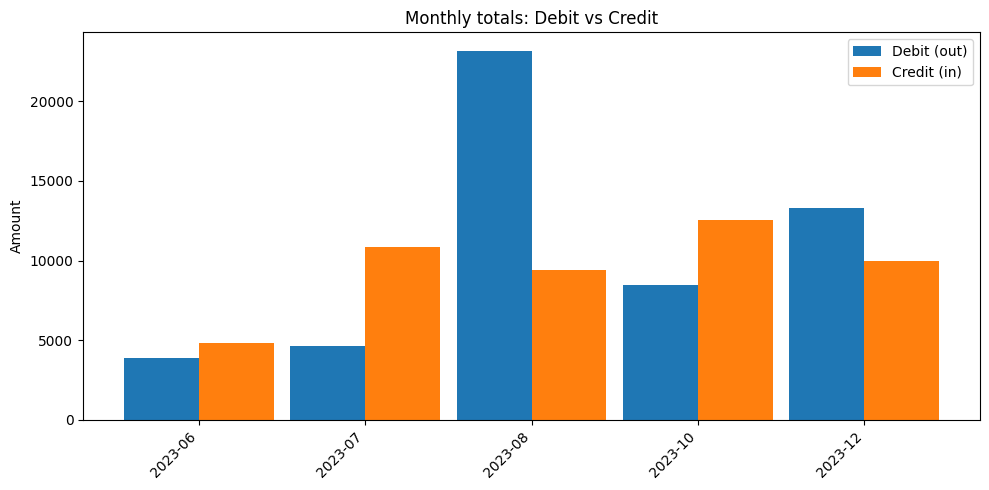

In [40]:
monthly = df.groupby(["month","type"])["amount"].sum().unstack(fill_value=0).sort_index()
plt.figure(figsize=(10,5))
x = np.arange(len(monthly.index))
w = 0.45
plt.bar(x - w/2, monthly.get("debit", 0), width=w, label="Debit (out)")
plt.bar(x + w/2, monthly.get("credit", 0), width=w, label="Credit (in)")
plt.xticks(ticks=x, labels=monthly.index, rotation=45, ha="right")
plt.ylabel("Amount")
plt.title("Monthly totals: Debit vs Credit")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "monthly_debit_credit.png"), dpi=160)
plt.show()


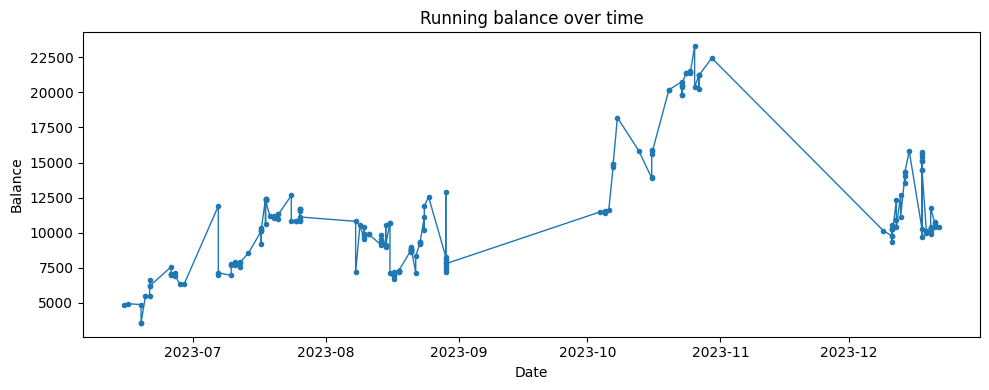

In [41]:
df_sorted = df.sort_values("date")
plt.figure(figsize=(10,4))
plt.plot(df_sorted["date"], df_sorted["balance"], marker=".", linewidth=1)
plt.title("Running balance over time")
plt.xlabel("Date")
plt.ylabel("Balance")
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "running_balance.png"), dpi=160)
plt.show()


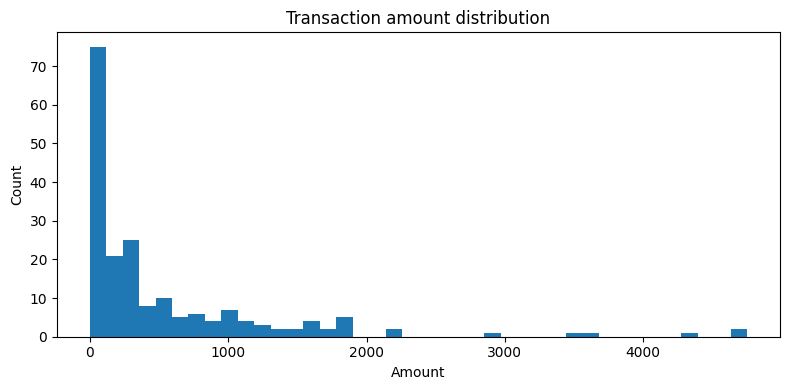

<Figure size 800x400 with 0 Axes>

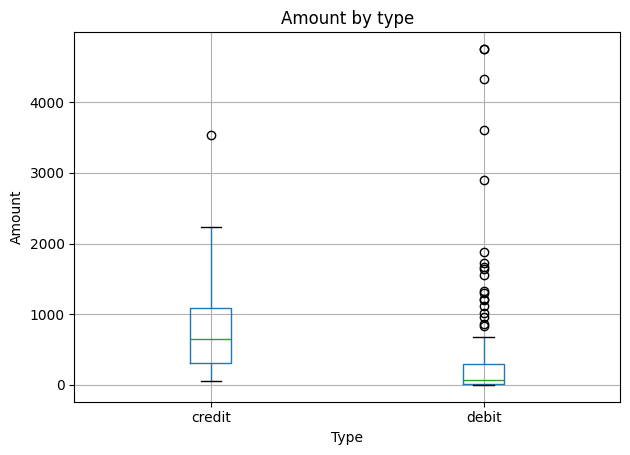

In [42]:
plt.figure(figsize=(8,4))
plt.hist(df["amount"].dropna(), bins=40)
plt.title("Transaction amount distribution")
plt.xlabel("Amount")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "amount_hist.png"), dpi=160)
plt.show()

plt.figure(figsize=(8,4))
df.boxplot(column="amount", by="type")
plt.title("Amount by type")
plt.suptitle("")
plt.xlabel("Type")
plt.ylabel("Amount")
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "amount_by_type_box.png"), dpi=160)
plt.show()


merchant
A AS                   4750.56
DONPO00DT 187324768    4750.00
GCTLTD T/A             4329.00
VANTAGE TOYOTA         3647.00
EEE OACCE3PARTS        3600.00
FO EEE                 3540.00
A EA                   2900.00
OTE SEO                2240.00
ANU CONONNT            2180.00
OTR EE                 1900.00
MOTTATS MOTOR          1880.74
. FE                   1860.00
NO_DESCRIPTION         1800.00
FESS                   1790.00
SE PETAL               1785.00
Name: amount, dtype: float64

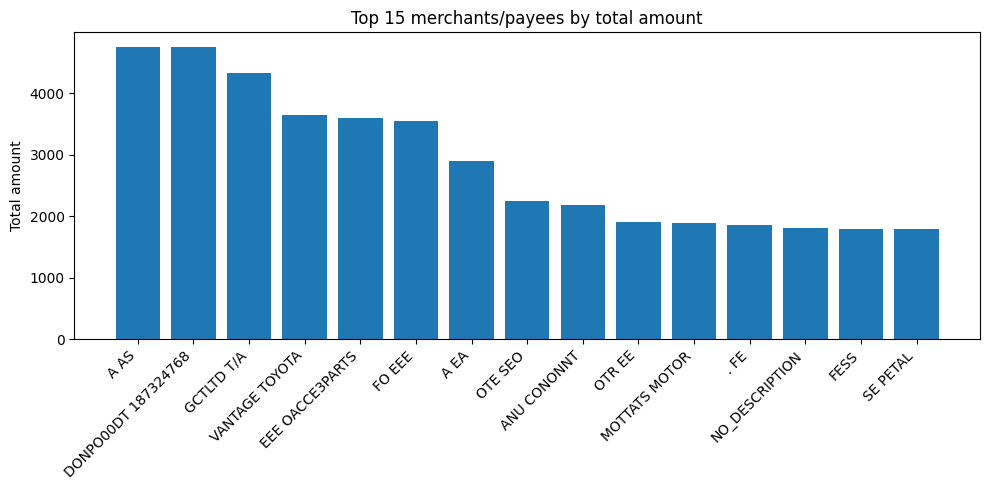

In [43]:
# Try to collapse common tokens like 'TESCO', 'EBAY', 'HMRC', 'AMAZON', 'FPI', 'FPO', 'RADIO', etc.
def extract_merchant(s: str) -> str:
    if not isinstance(s, str): return "OTHER"
    s = s.upper()
    # simple rules; add more as you see them in your data
    keywords = ["TESCO","SAINSBURY","MORRISONS","ASDA","ALDI","LIDL",
                "AMAZON","EBAY","PAYPAL","HMRC","VODAFONE","O2",
                "VANTAGE TOYOTA","SHELL","BP","TFL","TRANSPORT","UBER",
                "GOOGLE","APPLE","FEE","CHARGE","INTEREST","SAL","GUILTY CAR HIRE"]
    for k in keywords:
        if k in s:
            return k
    # fall back: first two words as a crude label
    parts = re.split(r"\s+", s)
    return " ".join(parts[:2]) if parts else "OTHER"

df["merchant"] = df["desc_clean"].apply(extract_merchant)

top_merchants = (df.groupby("merchant")["amount"]
                   .sum().sort_values(ascending=False).head(15))
display(top_merchants)

plt.figure(figsize=(10,5))
plt.bar(top_merchants.index, top_merchants.values)
plt.title("Top 15 merchants/payees by total amount")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Total amount")
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "top_merchants.png"), dpi=160)
plt.show()


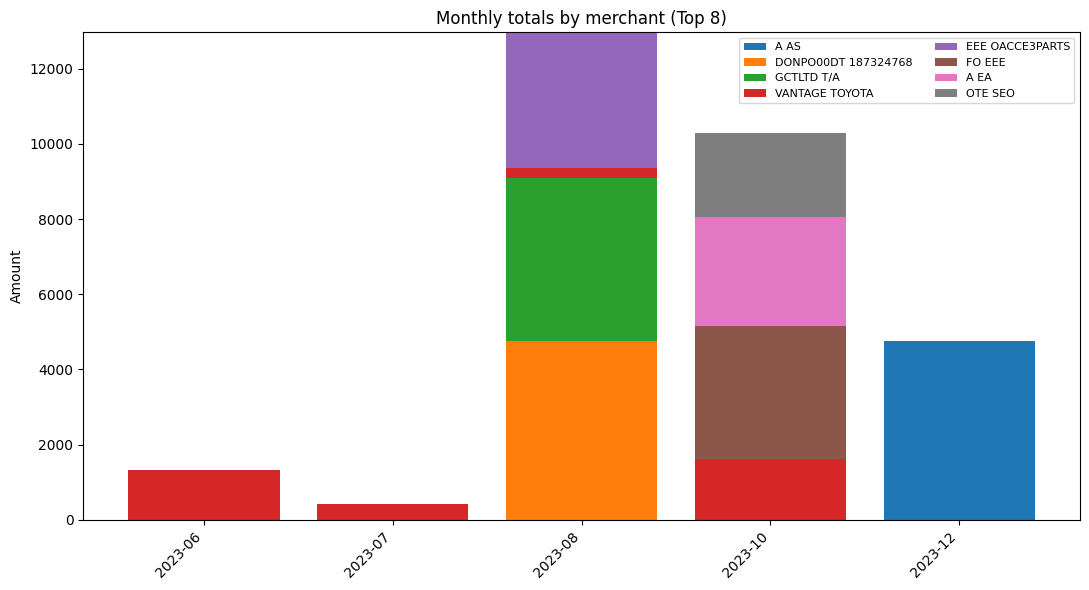

In [44]:
pivot = (df.pivot_table(index="month", columns="merchant", values="amount", aggfunc="sum", fill_value=0))
# keep the top N columns globally to keep plot readable
topN = 8
cols = df.groupby("merchant")["amount"].sum().sort_values(ascending=False).head(topN).index
pivot_small = pivot[cols].sort_index()

plt.figure(figsize=(11,6))
bottom = np.zeros(len(pivot_small))
x = np.arange(len(pivot_small.index))
for col in pivot_small.columns:
    plt.bar(x, pivot_small[col].values, bottom=bottom, label=col)
    bottom += pivot_small[col].values
plt.xticks(x, pivot_small.index, rotation=45, ha="right")
plt.title(f"Monthly totals by merchant (Top {topN})")
plt.ylabel("Amount")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "monthly_by_merchant_stacked.png"), dpi=160)
plt.show()


In [45]:
# largest debits and credits
largest_debits  = df[df["type"]=="debit"].nlargest(10, "amount")[["date","description","amount","balance"]]
largest_credits = df[df["type"]=="credit"].nlargest(10, "amount")[["date","description","amount","balance"]]
print("Top 10 debits:");  display(largest_debits)
print("Top 10 credits:"); display(largest_credits)


Top 10 debits:


,date,description,amount,balance
85,2023-12-18,a aS,4750.56,9679.19
53,2023-08-29,donpo00dT 187324768 PARTS,4750.00,8123.88
32,2023-08-08,GCTLTD T/A GTSE CD 0523,4329.00,7165.41
22,2023-08-16,eee oacce3paRTs,3600.00,7115.97
167,2023-10-26,a ea tas paRTs,2900.00,20395.31
147,2023-10-16,Mottats Motor Acc CD 0531,1880.74,13953.24
119,2023-07-18,Moffat's Motor Acc CD 0515,1729.20,10595.01
91,2023-12-20,eee eeorieS ost,1675.00,10085.74
42,2023-08-22,OTT et aE od1 PRIUS,1640.00,7149.25
19,2023-08-15,"GOUITY CAR HIRE LTENGINE Fpl 1,550.00 10,552.31",1550.00,10552.31


Top 10 credits:


,date,description,amount,balance
152,2023-10-08,FO eee een,3540.0,18200.77
172,2023-10-30,OTe Seo,2240.0,22446.59
114,2023-07-18,ANU CONONNT,2180.0,12416.92
178,2023-06-20,OTR ee MT,1900.0,5463.43
166,2023-10-26,. Fe SE So,1860.0,23295.31
33,2023-08-21,FESS,1790.0,8955.41
109,2023-07-17,Se petal,1785.0,10315.43
90,2023-12-20,Oe SE at,1600.0,11730.74
72,2023-12-13,Oe,1554.0,12663.24
77,2023-12-15,OT OS NSE bonat,1500.0,15809.25
